In [3]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification


2025-02-09 19:12:33.896807: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-09 19:12:33.899958: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-09 19:12:33.908233: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739146353.921583  867269 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739146353.926383  867269 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-09 19:12:33.943236: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [5]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score

/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [6]:
# pip install stepmix

In [7]:
myPredictorsDf = pd.read_csv('eICUPredictors.csv')

In [8]:
print(list(myPredictorsDf.columns))

['patientunitstayid', 'gender', 'age', 'apacheadmissiondx', 'admissionheight', 'hospitaladmittime24', 'hospitaladmitsource', 'admissionweight', 'PEA', 'Asystole', 'VTachy', 'VFib', 'Hypothermia', 'FirstGCSTime', 'FirstGCS', 'LastGCSTime', 'LastGCS', 'FirstMGCSTime', 'FirstMGCS', 'LastMGCSTime', 'LastMGCS', 'Lactate', 'Troponin', 'pH', 'Chloride', 'hospitaldischargestatus', 'DeathAtDischarge', 'LastGCS15', 'GCS Total', 'Heart Rate', 'Non-Invasive BP Diastolic', 'Non-Invasive BP Mean', 'Non-Invasive BP Systolic', 'O2 Admin Device', 'O2 L/%', 'O2 Saturation', 'Respiratory Rate', 'Temperature (C)', 'Temperature (F)', 'Temperature Location', 'Value', 'Invasive BP Diastolic', 'Invasive BP Systolic', 'Pain Score', 'CI', 'PVR', 'Bedside Glucose', 'Eyes', 'Motor', 'Verbal', 'Invasive BP Mean', 'Delirium Scale', 'Delirium Score', 'Sedation Scale', 'Sedation Score', 'CPP', 'End Tidal CO2', 'ICP', 'CVP', 'CO', 'SVO2', 'SV', 'Pain Goal', 'Sedation Goal', 'Electrolyte Replacement', 'IAP', 'PR', 'QRS

In [9]:
myPredictorsDf.select_dtypes(include=['object']).columns

Index(['gender', 'apacheadmissiondx', 'hospitaladmittime24',
       'hospitaladmitsource', 'FirstGCS', 'LastGCS', 'hospitaldischargestatus',
       'GCS Total', 'O2 Admin Device', 'Temperature Location', 'Value',
       'Delirium Scale', 'Delirium Score', 'Sedation Scale',
       'Electrolyte Replacement', 'Fall Risk'],
      dtype='object')

In [10]:
# myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int
myFilter = (myPredictorsDf['FirstGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['FirstGCS'].isna()) & (myPredictorsDf['LastGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastGCS'].isna())
myFilter = myFilter & (myPredictorsDf['FirstMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['FirstMGCS'].isna()) & (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
myFilter = myFilter & (myPredictorsDf['FirstMGCSTime'] != myPredictorsDf['LastMGCSTime']) & (myPredictorsDf['FirstGCSTime'] != myPredictorsDf['LastGCSTime'])
myPredictorsDf.loc[myPredictorsDf['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
myPredictorsDf.LastGCS15 = 0
myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int)
myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastMGCS'].astype(int) == 6).astype(int)

In [11]:
myPredictorsDf.columns

Index(['patientunitstayid', 'gender', 'age', 'apacheadmissiondx',
       'admissionheight', 'hospitaladmittime24', 'hospitaladmitsource',
       'admissionweight', 'PEA', 'Asystole',
       ...
       'Pressure Control', 'Vent Other', 'WBC's in peritoneal fluid',
       'Cyclosporin', 'Site', 'Amikacin - peak', 'PTT ratio',
       'Vancomycin - peak', 'LastGCSPositive', 'LastMGCSPositive'],
      dtype='object', length=230)

In [73]:
myXValue = myPredictorsDf.drop(columns= ['GCS Total', 'LastMGCSTime', 'FirstMGCSTime', 'Motor', 'LastMGCSPositive', 'LastMGCS', 'Sedation Scale', 'Electrolyte Replacement', 'Fall Risk', 'O2 Admin Device', 'Temperature Location', 'Value', 'Delirium Scale', 'Delirium Score', 'LastGCSPositive', 'apacheadmissiondx', 'hospitaladmittime24', 'FirstGCSTime', 'LastGCSTime', 'LastGCS', 'hospitaldischargestatus', 'LastGCS15', 'hospitaladmitsource', 'DeathAtDischarge', 'patientunitstayid'])
myXValue = myXValue[myFilter]
myXValue.FirstGCS = myXValue.FirstGCS.astype(int)
myYValue = myPredictorsDf[myFilter]['LastMGCSPositive']
myYValue = myYValue.astype(int)

X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[myFilter][['LastGCS15', 'Hypothermia']], test_size=0.3)

In [107]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    return [('preprocessor', myPreprocessor), ('imputer', SimpleImputer(missing_values=np.nan, strategy='mean')), ('pca', PCA(n_components=0.95))]
myPipelineSteps = getDefaultPipelineSteps(X_train)
myPipeline = Pipeline(myPipelineSteps)

In [108]:
X_train_transf = myPipeline.fit_transform(X_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

model = keras.Sequential([
    keras.Input(shape=(X_train_transf.shape[1],)), 
    layers.Dense(16, activation='relu'),  
    layers.Dense(1, activation='sigmoid') 
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name="roc_auc")])

In [109]:

history = model.fit(X_train_transf, y_train, epochs=30, batch_size=16, validation_data=(X_test_transf, y_test))


Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4411 - loss: 0.8807 - roc_auc: 0.4356 - val_accuracy: 0.5808 - val_loss: 0.6917 - val_roc_auc: 0.6020
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5986 - loss: 0.6815 - roc_auc: 0.6208 - val_accuracy: 0.6729 - val_loss: 0.6217 - val_roc_auc: 0.6961
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6914 - loss: 0.6230 - roc_auc: 0.7120 - val_accuracy: 0.6996 - val_loss: 0.5948 - val_roc_auc: 0.7259
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7247 - loss: 0.5700 - roc_auc: 0.7625 - val_accuracy: 0.7130 - val_loss: 0.5834 - val_roc_auc: 0.7397
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7069 - loss: 0.5493 - roc_auc: 0.7884 - val_accuracy: 0.7156 - val_loss: 0.5827 - val_roc_auc: 0.7419
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7416 - loss: 0.5141 - roc_auc: 0.8058 - val_accuracy: 0.7130 - val_loss: 0.5860 - val_roc_auc:

In [110]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'roc_auc', 'val_accuracy', 'val_loss', 'val_roc_auc'])

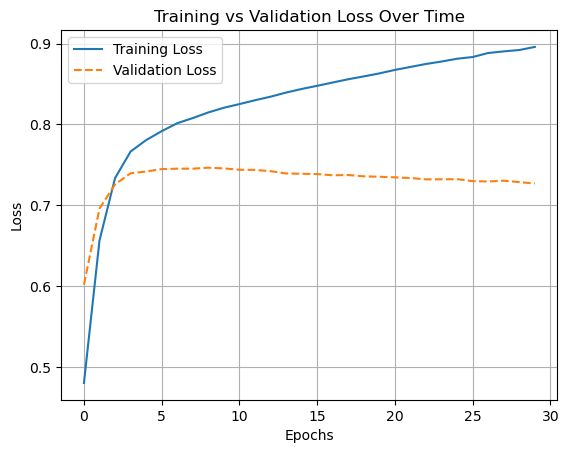

In [111]:
# Extract loss values
train_loss = history.history['roc_auc']
val_loss = history.history['val_roc_auc']

# Plot training & validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [112]:
X_train_transf.shape

(1746, 69)

In [113]:
y_pred_probs = model.predict(X_test_transf)  # Probabilities

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
ROC AUC Score: 0.7268


In [106]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Sample Dataset (Replace with real data)
# X = np.random.rand(1000, 20)  # 1000 samples, 20 features
# y = np.random.randint(0, 2, size=(1000,))  # Binary classification (0 or 1)

# Define Model Function
def create_model(optimizer="adam", neurons=16, activation="relu"):
    model = keras.Sequential([
        layers.Dense(neurons, activation=activation, input_shape=(X_train_transf.shape[1],)),
        layers.Dense(neurons // 2, activation=activation),
        layers.Dense(1, activation="sigmoid")  # Binary classification
    ])
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model

# Wrap model using scikeras
model = KerasClassifier(model=create_model, verbose=0)

# Define Hyperparameter Grid
param_grid = {
    "model__optimizer": ["adam", "rmsprop", "sgd"],
    "model__neurons": [8, 16, 32, 64],
    "model__activation": ["relu", "tanh"],
    "batch_size": [16, 32, 64],
    "epochs": [10, 20, 30]
}

# Use RandomizedSearchCV for faster tuning
random_search = RandomizedSearchCV(model, param_distributions=param_grid, cv=3, n_iter=10, scoring="accuracy", verbose=1)
random_search.fit(X_train_transf, y_train)

# Best Model and Hyperparameters
print("Best Hyperparameters:", random_search.best_params_)
print("Best AUC:", random_search.best_score_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


/home/idies/miniconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/idies/miniconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/idies/miniconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activi

Best Hyperparameters: {'model__optimizer': 'rmsprop', 'model__neurons': 8, 'model__activation': 'tanh', 'epochs': 20, 'batch_size': 64}
Best AUC: 0.7050400916380298


In [114]:
import shap
import numpy as np

# Ensure your data is in numpy array format for SHAP
X_train_np = X_train_transf.to_numpy()

# Explain predictions using KernelExplainer (for any model)
explainer = shap.KernelExplainer(model.predict, X_train_np)

# Compute SHAP values (only for a sample to speed up computation)
shap_values = explainer.shap_values(X_train_np[:100])  # Use a subset to reduce compute time

# Get mean absolute SHAP values for feature importance
shap_importance = np.abs(shap_values).mean(axis=0)

# Sort and display feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X_train_transf.columns,
    'SHAP Importance': shap_importance
}).sort_values(by='SHAP Importance', ascending=False)

print(feature_importance_df)


ImportError: Numba needs NumPy 1.24 or less

In [41]:
selected_features = X_train_transf.columns[selector.support_]
X_train_transf[selected_features]

AttributeError: 'RFECV' object has no attribute 'support_'

In [ ]:
myFeatureImportancesDf = getTopFeatures(myGridSearchCv, list(myBestModel.named_steps.preprocessor.get_feature_names_out()), X_train, y_train)

In [70]:
DefaultGrid = [
    {
        'clf': [XGBClassifier(eval_metric='logloss'), RandomForestClassifier()],
        'clf__n_estimators': [5, 10, 50, 200, 500], 
        'clf__max_depth': [2, 5, 10, 25, None]
    },
    {
        'clf': [DecisionTreeClassifier()],
        'clf__max_depth': [2, 5, 20, 50, None],
        'clf__class_weight': [None, 'balanced']
    },
    {
        'clf': [LogisticRegression(), SVC(probability=True, kernel='linear')],
        'clf__C': [0.1, 1, 10]
    }
]
def getPredictedTreatmentEffectSupervisedClassif(X_train, aModel, aCategory, aGroup):
    myXValueModified1 = X_train.copy()
    myXValueModified1[aGroup] = 1.0
    myXValueModified2 = X_train.copy()
    myXValueModified2[aGroup] = 0.0
    if hasattr(aModel, 'predict_proba'):
        y_pred_proba1 = aModel.predict_proba(myXValueModified1)[:, 1]
        y_pred_proba2 = aModel.predict_proba(myXValueModified2)[:, 1]
    else:
        y_pred_proba1 = aModel.predict(myXValueModified1).T[0]
        y_pred_proba2 = aModel.predict(myXValueModified2).T[0]
    myNewDf = pd.DataFrame()
    # print(y_pred_proba1)
    myNewDf['predicted_effect'] = (y_pred_proba1 - y_pred_proba2)
    
    return plotPredictedTreatmentEffect(myNewDf=myNewDf, aCategory=aCategory)
def getTreatmentEffectDiff(X_train, y_train, aModel, aCategory = 'CPC12', aGroup = 'groupe'):
    lower_third, upper_third, myNewDf = getPredictedTreatmentEffectSupervisedClassif(X_train, aModel, aCategory, aGroup)
    print(lower_third)
    print(upper_third)
    if upper_third == lower_third:
        print(f'No effect difference')
        return 1
    myData = pd.concat([X_train[aGroup], myNewDf['predicted_effect_group'], y_train], axis=1)
    model1 = smf.logit(
        f'{aCategory} ~ predicted_effect_group + {aGroup}',
        data=myData
    ).fit()

    model2 = smf.logit(
        f'{aCategory} ~ predicted_effect_group * {aGroup}',
        data=myData
    ).fit()

    llr = -2*(model1.llf - model2.llf)
    df_diff = model2.df_model - model1.df_model
    p_value = chi2.sf(llr, df_diff)

    print(f'Likelihood ratio of test results:')
    print(f'Chi square statistic: {llr}')
    print(f'p-value: {p_value}')
    print(f'Degress of freedom: {df_diff}')
    print(f'NonInteraction p-value: {model1.summary()}')
    print(f'Interaction p-value: {model2.summary()}')
    return p_value

In [72]:
y_train

1910    0
3110    0
1067    0
2307    1
2203    1
       ..
2244    0
674     0
939     0
146     0
350     1
Name: DeathAtDischarge, Length: 1746, dtype: int64

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 782us/step
-0.04575292269388835
-0.030531048774719242
Optimization terminated successfully.
         Current function value: 0.666165
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.665195
         Iterations 4
Likelihood ratio of test results:
Chi square statistic: 1.6985943734387092
p-value: 0.4277154304240368
Degress of freedom: 2.0
NonInteraction p-value:                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                  876
Model:                          Logit   Df Residuals:                      872
Method:                           MLE   Df Model:                            3
Date:                Sun, 09 Feb 2025   Pseudo R-squ.:                0.003374
Time:                        19:39:16   Log-Likelihood:                -583.56
converged:                       True   LL-Null

0.4277154304240368

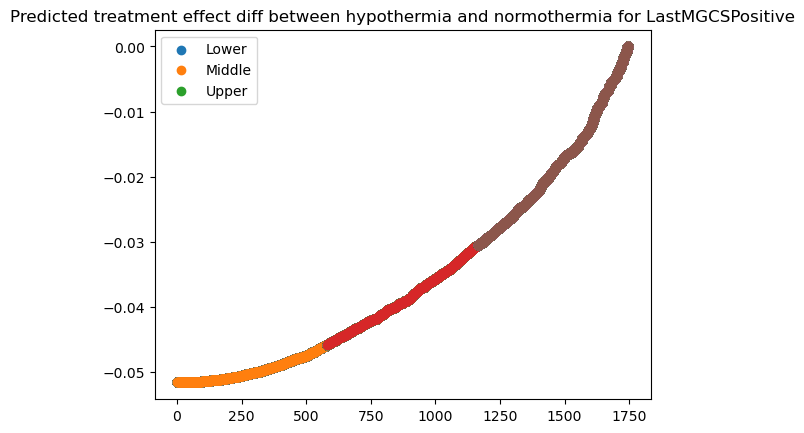

In [79]:
# getTreatmentEffectDiff(myXValue, myYValue, myBestModel, 'LastGCS15', 'Hypothermia')
# myNewDf = pd.DataFrame()
# myNewDf['predicted_effect_group'] = myBestModel.predict(X_test)
getTreatmentEffectDiff(X_train_transf, y_train, model, 'LastMGCSPositive', 'bin__Hypothermia')

In [56]:
[x for x in X_train_transf.columns if 'Hyp' in x]

['bin__Hypothermia']

-0.006000000000000005
0.001999999999999974
Optimization terminated successfully.
         Current function value: 0.654791
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.654027
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 1.0572722026490737
p-value: 0.589408314933102
Degress of freedom: 2.0
NonInteraction p-value:                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                  692
Model:                          Logit   Df Residuals:                      688
Method:                           MLE   Df Model:                            3
Date:                Sun, 02 Feb 2025   Pseudo R-squ.:                 0.01808
Time:                        19:09:05   Log-Likelihood:                -453.12
converged:                       True   LL-Null:                       -461.46
Covariance Type:            nonrobust   LLR p-valu

0.589408314933102

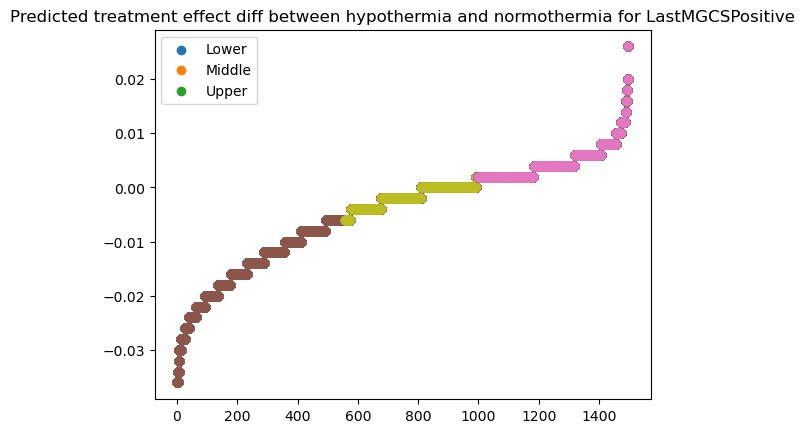

In [29]:
getTreatmentEffectDiff(X_train, y_train, myBestModel, 'LastMGCSPositive', 'Hypothermia')